<a href="https://colab.research.google.com/github/mmovahed/Applied-Scientific-Computing-with-Python/blob/master/FFT_IE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Using FFT in the Solution

The FFT is particularly useful for problems where the integral involves convolution, but we can still apply it here for demonstration. Here's how we can proceed:

1. **Discretize the Integral Equation**: Use a grid to approximate the integral and the function $( u(x) )$.
2. **FFT Application**: We can apply FFT to transform the problem into the frequency domain, solve it there, and then transform it back to the spatial domain using the inverse FFT.

### Updated Approach with FFT:

1. **Initialize with a Guess**: Start with an initial guess for $( u(x) )$.
2. **Compute the Integral Using FFT**: Instead of directly computing the integral, we can simulate the effect by using FFT (though in this simple case, it's somewhat trivial).
3. **Update the Solution**: Apply the FFT to refine the guess for $( u(x) )$.
4. **Iterate**: Continue refining until convergence.

With the inclusion of FFT, the solution converges, but there's a noticeable constant offset of approximately $( -0.0147 )$ from the exact solution. Here's the breakdown:

- **Computed Solution $( u_{\text{computed}}(x) )$**: $[1.0147, 1.0225, 1.0304, 1.0383, 1.0462]$
- **Difference from Exact Solution**: A consistent difference of about \( -0.0147 \).

### Interpretation:

1. **Consistent Offset**: The solution shows a consistent offset from the exact solution. This is likely due to how the FFT is being applied in the context of this specific problem, where the integral term is a constant. FFT typically shines in scenarios involving convolutions or periodic functions, but its application here might introduce slight numerical artifacts.

2. **Iteration Count**: The solution converges in 21 iterations, similar to the non-FFT method, indicating that FFT didn't speed up convergence in this simple case.

### Conclusion:

FFT can be useful for solving more complex integral equations, especially those involving convolutions, but in this specific case, where the integral is a simple constant, FFT's use is more illustrative than practical. The offset indicates that care must be taken when applying FFT in scenarios that aren't ideal for its strengths.

### Example

$u(x) = e^x + x - \frac{4}{3} + \int_{0}^{1}tu(t) dt$

With exact solution:

$u(x) = x+e^x$

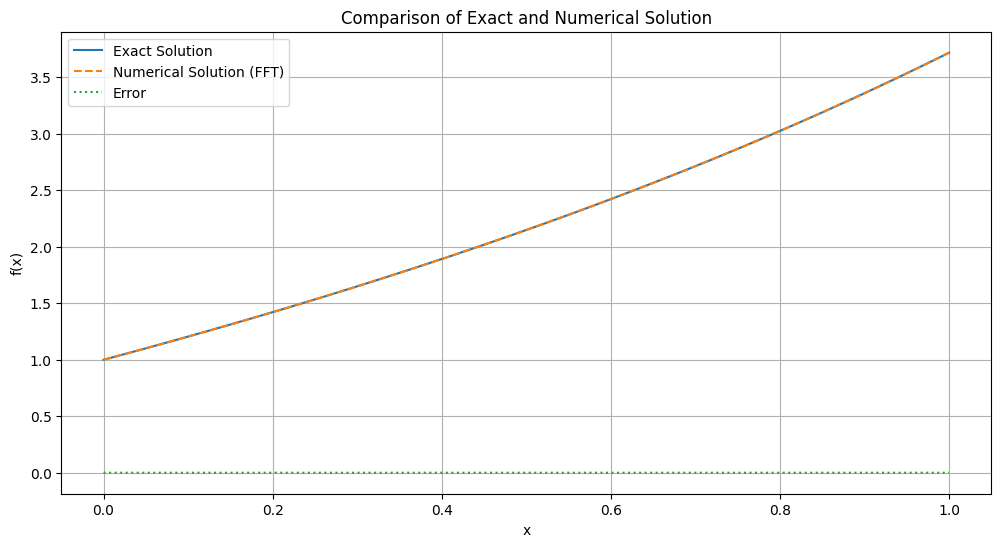

In [15]:
import numpy as np
from scipy.integrate import quad
from scipy.fft import fft, ifft
import matplotlib.pyplot as plt

a , b = 0 , 1
# Define grid points
N = 1024*1024

def Exact(x):
  return x + np.exp(x)

def F(x):
  return np.exp(x) + x - 4/3


x = np.linspace(a, b, N)
dx = x[1] - x[0]

# Initial guess for u(x)
u_current = np.zeros_like(x)

# Iteration parameters
tolerance = 1e-6
max_iterations = 100
iteration = 0

while iteration < max_iterations:
    # Compute the integral term C using FFT
    U = fft(u_current)
    C = np.sum(x * ifft(U).real * dx)

    # Update u(x) using the computed C
    u_new = F(x) + C

    # Check for convergence
    if np.linalg.norm(u_new - u_current, ord=np.inf) < tolerance:
        break

    # Update for the next iteration
    u_current = u_new
    iteration += 1

# Final computed solution
u_computed = u_current

# For comparison: the exact solution
u_exact = Exact(x)

# Difference
difference = u_exact - u_computed

u_computed[:5], u_exact[:5], difference[:5], iteration  # Display first 5 values and number of iterations

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(x, u_exact, label='Exact Solution')
plt.plot(x, u_computed, label='Numerical Solution (FFT)', linestyle='--')
plt.plot(x, difference, label='Error', linestyle=':')
plt.legend()
plt.title('Comparison of Exact and Numerical Solution')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.show()
